In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("orders_forecasting.csv")

# Convert Date
df["order_date"] = pd.to_datetime(df["order_date"], format="%d-%m-%Y %H:%M")
df = df.rename(columns={"order_date": "ds", "order_total": "y"})


In [ ]:
daily_sales = df.groupby(df["ds"].dt.date)["y"].sum().reset_index()
daily_sales.columns = ["ds", "y"]
daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

In [ ]:
holidays = pd.DataFrame({
    'holiday': 'indian_festival',
    'ds': pd.to_datetime([
        '2023-10-24', '2024-11-01',  # Diwali
        '2024-03-25', '2023-03-08',  # Holi
        '2023-08-15', '2024-08-15',  # Independence Day
        '2023-10-02', '2024-10-02',  # Gandhi Jayanti
    ]),
    'lower_window': -1,
    'upper_window': 1,
})

In [ ]:
model = Prophet(
    seasonality_mode='multiplicative',
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=holidays
)
model.fit(daily_sales)

In [ ]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

In [ ]:
fig1 = model.plot(forecast)

# Trend + Seasonality breakdown graph
plt.title("Sales Forecast - Next 30 Days")
plt.show()
fig2 = model.plot_components(forecast)
plt.show()

19:22:03 - cmdstanpy - INFO - Chain [1] start processing
19:22:03 - cmdstanpy - INFO - Chain [1] done processing


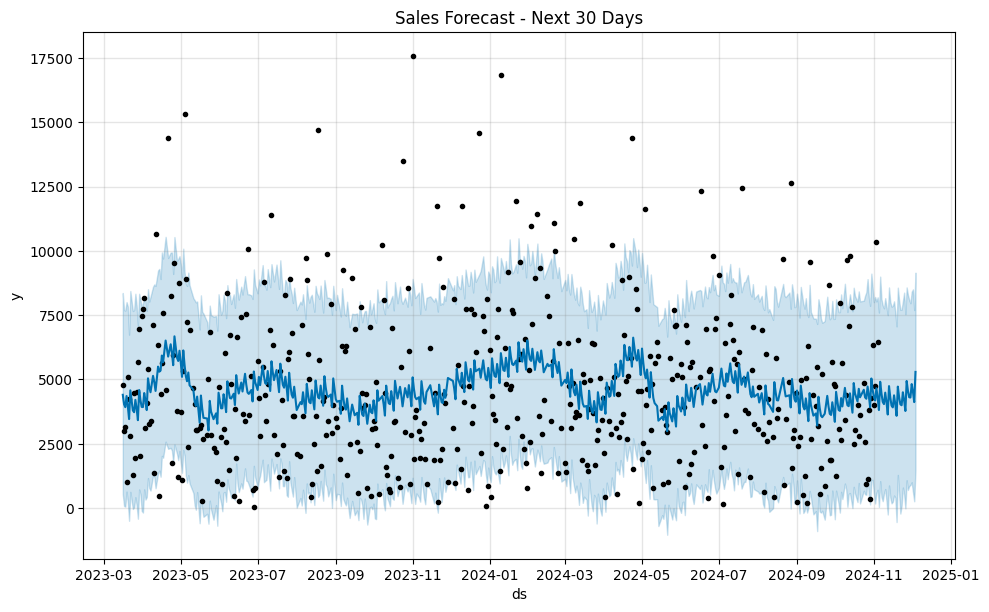

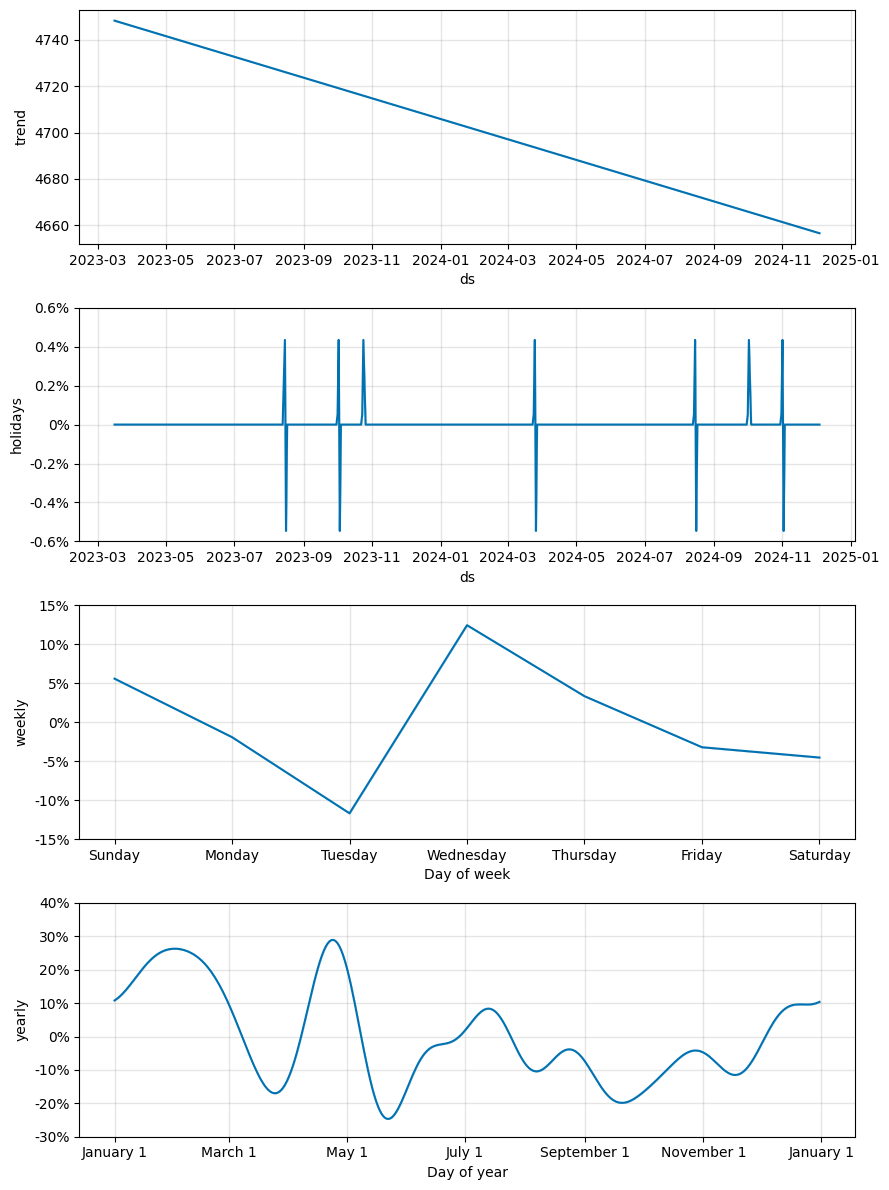

Done! Forecast saved.


In [4]:

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(
    "forecast_results.csv", index=False
)
print("Done! Forecast saved.")